# Firm size structure and value added

This notebook uses Eurostat Structural Business Statistics to examine firm-size patterns in Italy and selected European peers. It focuses on the distribution of enterprises by size class and value added per person employed.

In [1]:
# %pip install -r requirements.txt

## Enterprises in Italy by size class

The first chart filters Eurostat data for Italy, the total business economy and the number-of-enterprises indicator. It shows how Italian enterprises are distributed across employment-size classes.

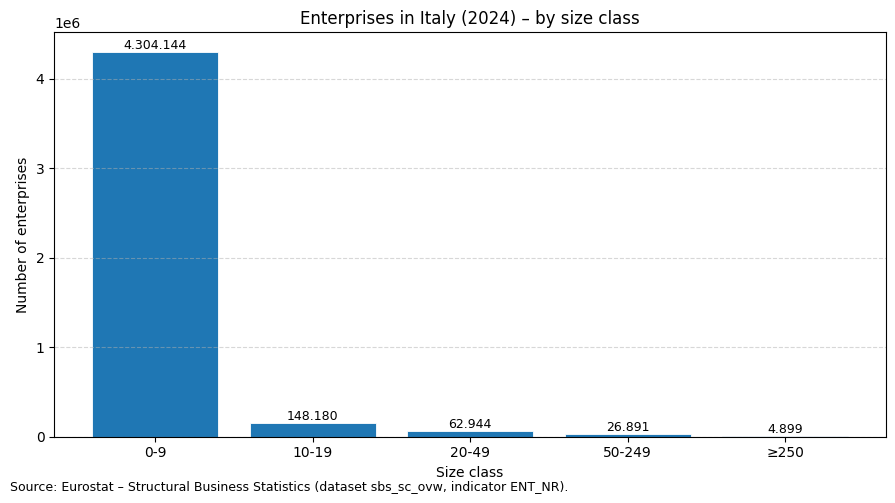

In [2]:
import eurostat
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
DATASET = "sbs_sc_ovw"
GEO_COL = "geo\\TIME_PERIOD"
NACE_TOTAL = "B-S_X_O_S94"
YEAR = "2024"
SIZE_ORDER = ["0-9", "10-19", "20-49", "50-249", "GE250"]

# 1) Eurostat data
df = eurostat.get_data_df(DATASET)

# 2) Filter Italy, total economy, indicator: number of enterprises
f = (
    (df[GEO_COL] == "IT") &
    (df["nace_r2"] == NACE_TOTAL) &
    (df["indic_sbs"] == "ENT_NR") &
    (df["size_emp"].isin(SIZE_ORDER))
)
it = df.loc[f, ["size_emp", YEAR]].copy()
it[YEAR] = pd.to_numeric(it[YEAR], errors="coerce")
it["size_emp"] = pd.Categorical(it["size_emp"], categories=SIZE_ORDER, ordered=True)
it = it.sort_values("size_emp").set_index("size_emp")

# 3) Rename GE250 -> ≥250
it = it.rename(index={"GE250": "≥250"})

# 4) Chart with blue bars
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(it.index, it[YEAR].values, color="#1f77b4", edgecolor="white", linewidth=0.6)

# Labels above bars
for b, v in zip(bars, it[YEAR].values):
    label = f"{int(round(v)):,}".replace(",", ".")
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Enterprises in Italy (2024) – by size class")
ax.set_xlabel("Size class")
ax.set_ylabel("Number of enterprises")
ax.grid(axis="y", linestyle="--", alpha=0.5)
fig.tight_layout()
fig.text(
    0.01,
    0.01,
    "Source: Eurostat – Structural Business Statistics (dataset sbs_sc_ovw, indicator ENT_NR).",
    ha="left",
    fontsize=9
)

plt.show()

## Cross-country comparison by size class

The second part compares Italy, France, Germany and Spain using the latest year with available data. It produces grouped bar charts for enterprise shares and labour productivity by firm size.

Selected year: 2023


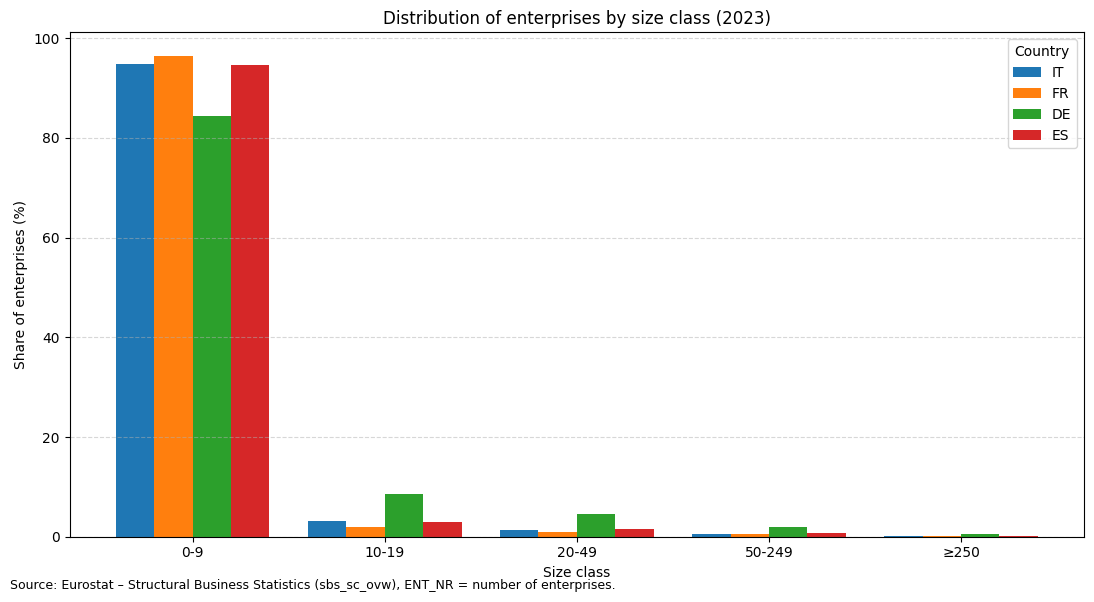

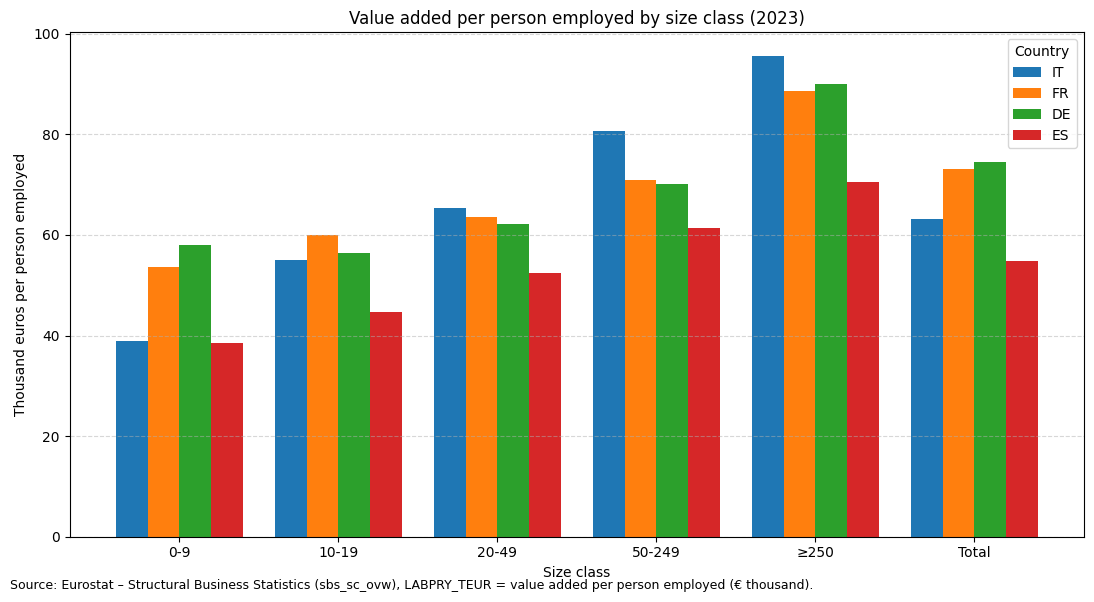

In [3]:
import eurostat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET = "sbs_sc_ovw"
countries = ["IT", "FR", "DE", "ES"]

# Order with TOTAL at the end and GE250 renamed later
size_order = ["0-9", "10-19", "20-49", "50-249", "GE250", "TOTAL"]
geo_col = "geo\\TIME_PERIOD"
nace_total = "B-S_X_O_S94"

IND_ENT = "ENT_NR"        # number of enterprises
IND_LAB = "LABPRY_TEUR"   # value added per person employed (€ thousand)

df = eurostat.get_data_df(DATASET)
year_cols = [c for c in df.columns if c.isdigit() and len(c) == 4]
year_cols.sort()

base = df[
    (df[geo_col].isin(countries)) &
    (df["nace_r2"] == nace_total) &
    (df["size_emp"].isin(size_order))
].copy()

def last_common_year(base, ind_codes):
    years = list(reversed(year_cols))
    for y in years:
        ok = True
        for ind in ind_codes:
            z = base[base["indic_sbs"] == ind]
            need = len(countries) * len(size_order)
            have = z[y].notna().sum()
            if have < need:
                ok = False
                break
        if ok:
            return y
    raise ValueError("No complete year found.")

year = last_common_year(base, [IND_ENT, IND_LAB])
print("Selected year:", year)

def make_pivot(ind):
    z = base[base["indic_sbs"] == ind].copy()
    z[year] = pd.to_numeric(z[year], errors="coerce")
    z["size_emp"] = pd.Categorical(z["size_emp"], categories=size_order, ordered=True)
    p = z.pivot(index="size_emp", columns=geo_col, values=year).loc[size_order, countries]

    # Rename GE250
    p = p.rename(index={"GE250": "≥250"})
    return p

pivot_ent = make_pivot(IND_ENT)
pivot_lab = make_pivot(IND_LAB)

# Percentage shares by country, excluding TOTAL, which remains an absolute value
pivot_ent_share = pivot_ent.drop(index="TOTAL")
pivot_ent_share = pivot_ent_share.div(
    pivot_ent_share.loc[["0-9", "10-19", "20-49", "50-249", "≥250"]].sum(axis=0),
    axis=1
) * 100

# Rename TOTAL in the second pivot
pivot_lab = pivot_lab.rename(index={"TOTAL": "Total"})

def grouped_bars(pivot_df, ylabel, title, note):
    X = np.arange(len(pivot_df.index))
    m = len(pivot_df.columns)
    width = 0.8 / m

    fig, ax = plt.subplots(figsize=(11, 6))
    for j, col in enumerate(pivot_df.columns):
        ax.bar(X + (j - (m - 1) / 2) * width, pivot_df[col].values, width, label=col)

    ax.set_xticks(X)
    ax.set_xticklabels(pivot_df.index)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Size class")
    ax.set_title(f"{title} ({year})")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(title="Country")
    fig.tight_layout()
    fig.text(0.01, 0.01, note, ha="left", fontsize=9)
    plt.show()

# Charts
grouped_bars(
    pivot_ent_share,
    ylabel="Share of enterprises (%)",
    title="Distribution of enterprises by size class",
    note="Source: Eurostat – Structural Business Statistics (sbs_sc_ovw), ENT_NR = number of enterprises."
)

grouped_bars(
    pivot_lab,
    ylabel="Thousand euros per person employed",
    title="Value added per person employed by size class",
    note="Source: Eurostat – Structural Business Statistics (sbs_sc_ovw), LABPRY_TEUR = value added per person employed (€ thousand)."
)